# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [14]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

In [16]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


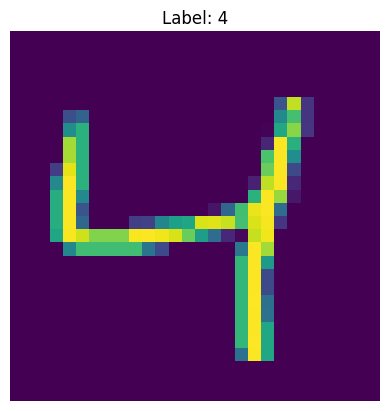

In [17]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [4]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [6]:
# ANN Model
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: 입력층 --> 은닉층  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = torch.nn.Linear(input_dim,hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = torch.nn.ReLU()

        # Linear function 2: 은닉층 --> 은닉층  (숨겨진 계층을 한 번 더 통과)
        self.fc2 = torch.nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = torch.nn.Tanh()

        # Linear function 3: 은닉층 --> 은닉층  (추가 숨겨진 계층)
        self.fc3 = torch.nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = torch.nn.ELU()

        # Linear function 4: 은닉층 --> 출력층  (마지막 출력층)
        self.fc4 = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3(out)

        # Linear function 4
        out = self.fc4(out)  # 마지막 출력층
        return out

In [7]:
# ANN 객체 생성
input_dim = 784  # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5  # 출력 클래스 개수 (0~4)


model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss() # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#### **ANN 모델 학습**

In [8]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1,784)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1, 784)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs = model(test)

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))


Iteration: 500  Loss: 0.16980579495429993  Accuracy: 96.14710998535156 %
Iteration: 1000  Loss: 0.1160346269607544  Accuracy: 96.8087158203125 %
Iteration: 1500  Loss: 0.06808068603277206  Accuracy: 97.54816436767578 %
Iteration: 2000  Loss: 0.27447813749313354  Accuracy: 97.7232894897461 %
Iteration: 2500  Loss: 0.11429928988218307  Accuracy: 97.87896728515625 %
Iteration: 3000  Loss: 0.01394705567508936  Accuracy: 98.07355499267578 %
Iteration: 3500  Loss: 0.045768894255161285  Accuracy: 98.07355499267578 %
Iteration: 4000  Loss: 0.040870361030101776  Accuracy: 98.32652282714844 %
Iteration: 4500  Loss: 0.11765894293785095  Accuracy: 98.32652282714844 %


#### **ANN 학습 결과**

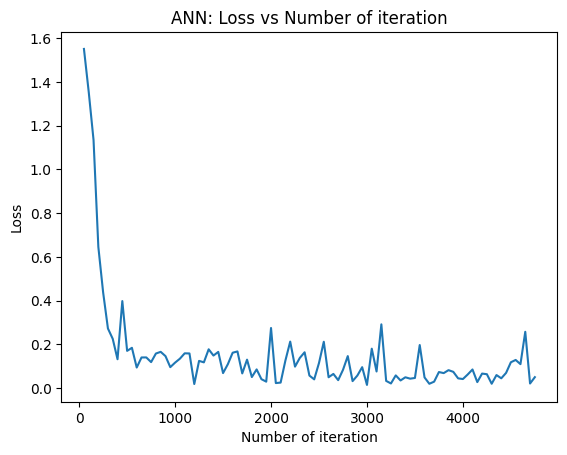

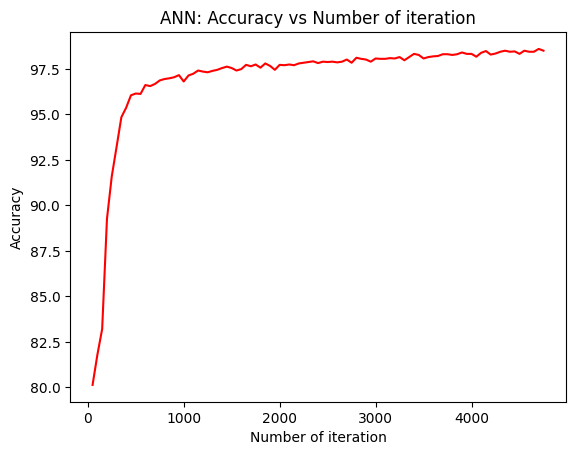

In [9]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗



---
**[해석]**
-
-


#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

In [29]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Assume ANNModel, train_loader, and test_loader are already defined

# ANN 객체 생성
input_dim = 784
output_dim = 5
loss_ftn = nn.CrossEntropyLoss()
learning_rate = 0.02

# 실험에 사용할 hidden_dim 값들
hidden_dims_to_test = [50, 100, 150, 200]
results = {} # 결과를 저장할 딕셔너리

for h_dim in hidden_dims_to_test:
    print(f"--- Training model with hidden_dim = {h_dim} ---")

    # 각 hidden_dim에 대해 새로운 모델과 옵티마이저 생성
    model = ANNModel(input_dim, h_dim, output_dim)
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    # 학습을 모니터링하기 위한 리스트 초기화
    loss_list = []
    accuracy_list = []

    count = 0
    for epoch in range(10): # 전체 학습
        for i, (images, labels) in enumerate(train_loader):
            train = images.view(-1, 784)
            labels = labels

            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)
            loss.backward()
            optimizer.step()
            count += 1

            if count % 50 == 0:
                correct = 0
                total = 0

                # 테스트 데이터셋에서 정확도 계산 (경사 계산 비활성화)
                with torch.no_grad():
                    for test_images, test_labels in test_loader:
                        test = test_images.view(-1, 784)
                        outputs = model(test)
                        predicted = torch.max(outputs.data, 1)[1]
                        total += len(test_labels)
                        correct += (predicted == test_labels).sum().item()

                accuracy = 100 * correct / float(total)
                loss_list.append(loss.item())
                accuracy_list.append(accuracy)

    results[h_dim] = {'loss': loss_list, 'accuracy': accuracy_list}

--- Training model with hidden_dim = 50 ---
--- Training model with hidden_dim = 100 ---
--- Training model with hidden_dim = 150 ---
--- Training model with hidden_dim = 200 ---


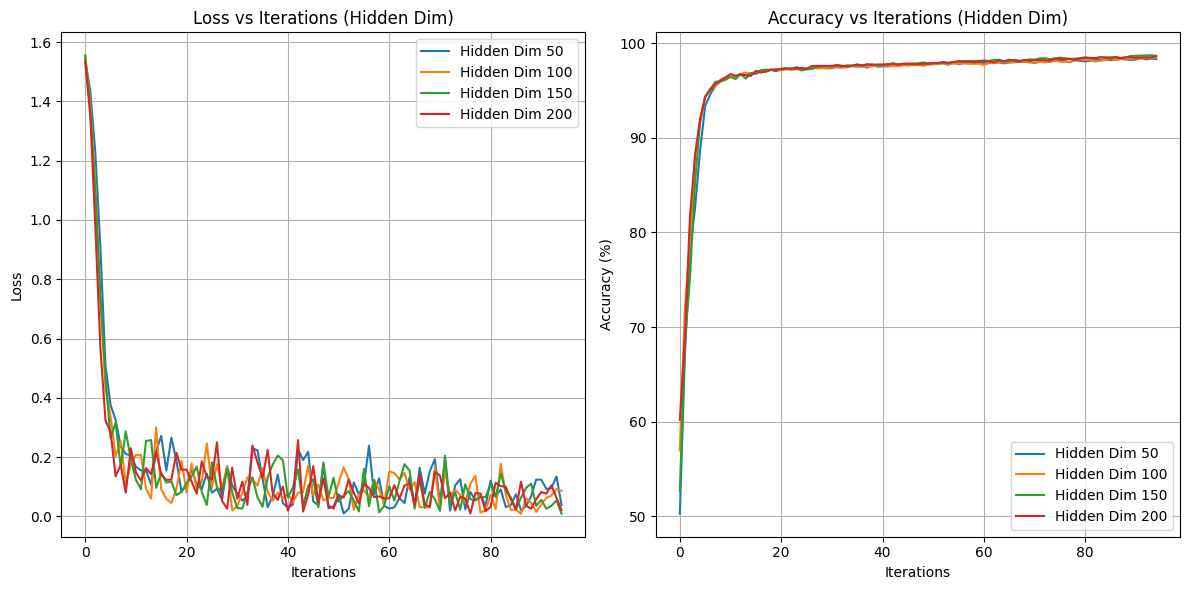

In [31]:
# 실험 1 모델 학습 결과 시각화
# 결과 시각화
plt.figure(figsize=(12, 6))

# Loss 그래프
plt.subplot(1, 2, 1)
for h_dim, data in results.items():
    plt.plot(data['loss'], label=f'Hidden Dim {h_dim}')
plt.title('Loss vs Iterations (Hidden Dim)')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy 그래프
plt.subplot(1, 2, 2)
for h_dim, data in results.items():
    plt.plot(data['accuracy'], label=f'Hidden Dim {h_dim}')
plt.title('Accuracy vs Iterations (Hidden Dim)')
plt.xlabel('Iterations')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- hideen dimension이 너무 적을 때는 과소적합이 발생하고, 너무 클 때는 과적합이 발생할 수 있다.
- 따라서, 적절한 hidden dimension 값을 찾아내 최적의 성능을 발휘할 수 있도록 해야한다.
-

In [32]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습
def run_experiment_learning_rate(lr):

    # hidden_dim =150으로 고정
    model = ANNModel(input_dim=784, hidden_dim=150, output_dim=5)
    loss_ftn = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    loss_list = []
    accuracy_list = []

    for epoch in range(10):
        for i, (images, labels) in enumerate(train_loader):
            train = images.view(-1, 784)
            labels = labels

            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)
            loss.backward()
            optimizer.step()

            if (i+1) % 50 == 0:
                correct = 0
                total = 0
                with torch.no_grad():
                    for test_images, test_labels in test_loader:
                        test = test_images.view(-1, 784)
                        outputs = model(test)
                        predicted = torch.max(outputs.data, 1)[1]
                        total += len(test_labels)
                        correct += (predicted == test_labels).sum().item()
                accuracy = 100 * correct / total
                loss_list.append(loss.item())
                accuracy_list.append(accuracy)
    return loss_list, accuracy_list

# 실험 실행
learning_rates_to_test = [0.1, 0.05, 0.01, 0.005]
results_lr = {lr: run_experiment_learning_rate(lr) for lr in learning_rates_to_test}


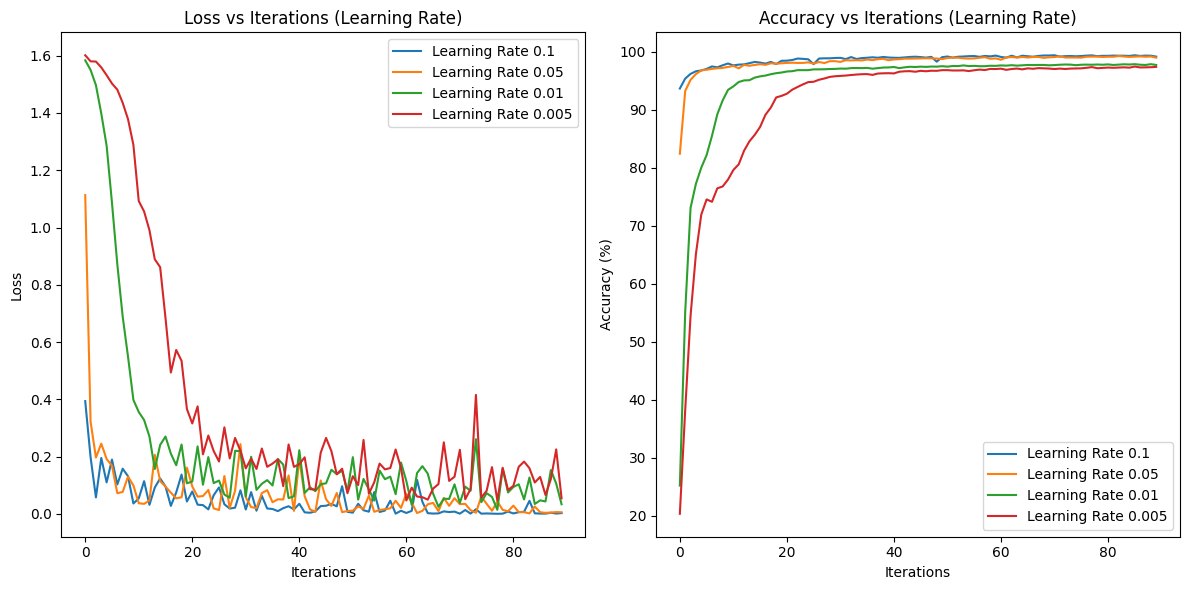

In [34]:
# 실험 2 모델 학습 결과 시각화
plt.figure(figsize=(12, 6))

# Loss 그래프
plt.subplot(1, 2, 1)
for lr, (losses,_) in results_lr.items():
    plt.plot(losses, label=f'Learning Rate {lr}')
plt.title('Loss vs Iterations (Learning Rate)')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()

# Accuracy 그래프
plt.subplot(1, 2, 2)
for lr, (_, accuracies) in results_lr.items():
    plt.plot(accuracies, label=f'Learning Rate {lr}')
plt.title('Accuracy vs Iterations (Learning Rate)')
plt.xlabel('Iterations')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- learning rate가 클수록 초반부터 손실이 급격하게 줄고 높은 정확도를 갖지만 불안정하다.
- 너무 작은 learning rate는 정확도가 높아지는 속도가 너무 느리다.
- 따라서 적절한 학습률을 찾는 것이 중요하다.

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()  # 활성화 함수 (ReLU)
        ## (28-5+0)/1 + 1 = 24
        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정
        ## 24/2 = 12
        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()  # 활성화 함수 (ReLU)
        # (12-5+0)/1 + 1 = 8
        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정
        # 8/2 = 4
        # Fully Connected Layer
        self.fc1 = nn.Linear(32*4*4, 5)  # 입력 차원 및 출력 차원 지정

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)

        # feature map을 flatten하게
        out = out.view(out.size(0), -1)

        # 완전 연결 계층
        out = self.fc1(out)

        return out

In [23]:
# CNN 객체 생성
model = CNNModel()
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.SGD(model.parameters(), lr=0.01)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [24]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 20  # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # Reshape images for CNN input (batch_size, channels, height, width)
        images = images.view(images.size(0), 1, 28, 28)

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # 손실 계산
        loss = loss_ftn(outputs, labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images, labels in test_loader:
                    # Reshape images for CNN input (batch_size, channels, height, width)
                    test_images = images.view(images.size(0), 1, 28, 28)

                    # 모델 예측 수행
                    outputs = model(test_images)

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.max(outputs.data, 1)[1]

                    # 총 샘ples 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 0.5163223776453036
Epoch 2, Loss: 0.13383746264980706
Epoch 3, Loss: 0.11183336501385013
Epoch 4, Loss: 0.09608176395312605
Epoch 5, Loss: 0.08390733264464426
Epoch 6, Loss: 0.07407042080447046
Epoch 7, Loss: 0.06586341112988198
Epoch 8, Loss: 0.05915638480417135
Epoch 9, Loss: 0.0525673906545355
Epoch 10, Loss: 0.048504842678571046
Epoch 11, Loss: 0.04488081639119286
Epoch 12, Loss: 0.041098978744220915
Epoch 13, Loss: 0.038569624764681454
Epoch 14, Loss: 0.0359555336312315
Epoch 15, Loss: 0.03401744861574283
Epoch 16, Loss: 0.03227196748772858
Epoch 17, Loss: 0.030683335006754214
Epoch 18, Loss: 0.029447706535398778
Epoch 19, Loss: 0.02807301112558447
Epoch 20, Loss: 0.02637399501645537


#### **CNN 학습 결과**

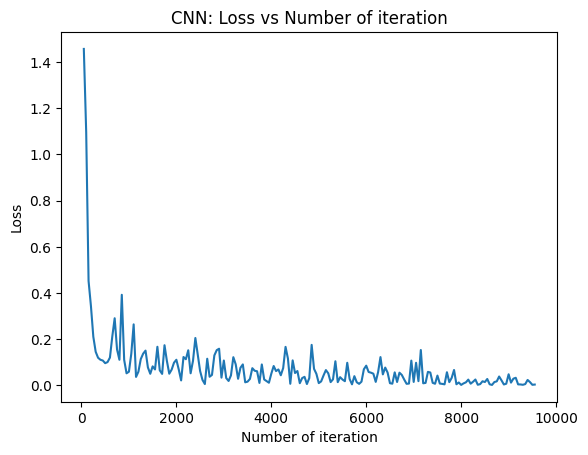

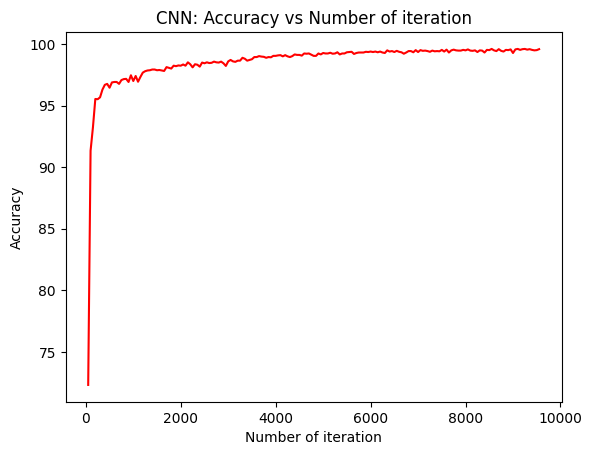

In [28]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**
- ANN은 손실값이 매우 요동치는 듯한 모습을 보였지만, CNN이 상대적으로 더 높은 정확도와 안정성을 보였다.
- ANN은 이미지 데이터를 1차원으로 변환하여 이미지의 공간정보를 누락시키지만, CNN은 이미지의 기존 차원을 그대로 처리하고 과적합도 방지하여 더 높은 정확도를 낼 수 있다.
